In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# Observed Bus In-Vehicle Time from the Bus-Speed Network — GTFS Trips Routed over Measured Link Speeds

Step 29 produced the **scheduled** bus in-vehicle time between the 25 V2 corridor areas straight from the GTFS timetable. This notebook builds an **observed** counterpart: every morning-peak GTFS bus trip's stop-to-stop sequence is routed, stop by stop, over a street network that carries **measured bus link speeds** (May 2026 Bus Speed Data, weekday 3 = Tuesday, 07:00–08:00), and the resulting running time is compared with the timetable.

**Inputs.** `Output/gtfs/stops_study_area.csv` and `stop_times_study_area_am_trips.csv.gz` (step 29's intermediates: every study-area stop of every trip with a morning departure, 06:00–09:00); the street network `Input/BusSpeedData/Streets/Streets.shp` with per-link, per-direction bus speeds `Input/BusSpeedData/std_202605.csv` (weekday 3, hour 7); the 25 V2 areas `Input/Corridor_TAZ_Agg_V2.xlsx`; step 29's scheduled skim `Output/gtfs/bus_direct_skim_area_v2.csv` for a consistency check.

**Method.**
**A.** Every study-area stop is snapped to its nearest street-network node (cKDTree).
**B.** The distinct consecutive stop-to-stop pairs across every trip's sequence are routed once each (not per trip) — shortest path **by length** on the directed graph (dijkstra, per source node, predecessors recovered to walk the path).
**C.** Per routed pair: the length and time on links that carry a measured speed, plus the remaining (uncovered) length extrapolated at the segment's own covered average speed. Segments whose directed path is unreachable or implausibly long (more than 2.5 × the straight line, or over 8 km — mostly short hops where a stop snapped to the far end of a one-way link forces a loop around the block) are routed again ignoring link direction and accepted if plausible; what still fails falls back to the scheduled time, flagged.
**D.** Every trip's stop sequence is walked cumulatively to get an observed and a scheduled in-vehicle time.
**E.** An area-to-area skim is built exactly as step 29's (first stop in the origin area to the first, later, stop in the destination area, on trips departing the origin 06:00–09:00), with an observed and a scheduled median per pair, for all buses and for BRT only.

**Caveats.** The link speeds are *space-mean* bus speeds per link and hour from AVL data; whether they include dwell time at stops along the link is not documented, so the observed ÷ scheduled ratio below (which nets out dwell if the timetable already prices it in) is itself the best evidence on that question. Routing by shortest length approximates — but does not guarantee — the actual path a bus takes between two consecutive stops. Segments with no measured link fall back to the schedule and are flagged, not silently dropped.

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapefile
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

BLUE, ORANGE, AQUA, PURPLE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
OUT = 'Output/gtfs'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
plt.rcParams.update({'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'text.color': INK, 'xtick.color': INK2, 'ytick.color': INK2, 'font.size': 10})
AM = (6 * 3600, 9 * 3600); PEAK = (7 * 3600, 8 * 3600)

STOPS_P, ST_P = f'{OUT}/stops_study_area.csv', f'{OUT}/stop_times_study_area_am_trips.csv.gz'
assert os.path.exists(STOPS_P) and os.path.exists(ST_P), 'run step 29 (GTFS_bus_LOS_TAZ.ipynb) on the real feed first: it writes the stop and stop-time intermediates this notebook reads'

## 1. Street network with measured bus speeds, and stop snapping (A)

In [3]:
sp = pd.read_csv('Input/BusSpeedData/std_202605.csv', usecols=['USERID', 'd_3_h_7_AB', 'd_3_h_7_BA']).set_index('USERID')
rd = shapefile.Reader('Input/BusSpeedData/Streets/Streets'); BB = (187919, 697664, 284139, 804470)
edges = []
for s, rec in zip(rd.iterShapes(), rd.iterRecords()):
    b = s.bbox
    if not (b[2] > BB[0] and b[0] < BB[2] and b[3] > BB[1] and b[1] < BB[3]): continue
    p = s.points; ln = sum(np.hypot(p[i + 1][0] - p[i][0], p[i + 1][1] - p[i][1]) for i in range(len(p) - 1))
    edges.append((p[0][0], p[0][1], p[-1][0], p[-1][1], ln, rec['DIR'], rec['USERID']))
e = pd.DataFrame(edges, columns=['ax', 'ay', 'bx', 'by', 'len', 'dir', 'uid'])
e['vAB'] = e['uid'].map(sp['d_3_h_7_AB']).fillna(0); e['vBA'] = e['uid'].map(sp['d_3_h_7_BA']).fillna(0)
nodes = {}
def node(x, y):
    k = (round(x), round(y))
    if k not in nodes: nodes[k] = len(nodes)
    return nodes[k]
e['a'] = [node(x, y) for x, y in zip(e['ax'], e['ay'])]; e['b'] = [node(x, y) for x, y in zip(e['bx'], e['by'])]
N = len(nodes); node_xy = np.array([k for k, _ in sorted(nodes.items(), key=lambda kv: kv[1])])
# directed edges for ALL links (routable everywhere), weight = length; per-direction measured speed kept (0 = none)
du, dv, dlen, dspd = [], [], [], []
for a, b, ln, dr, vab, vba in zip(e['a'], e['b'], e['len'], e['dir'], e['vAB'], e['vBA']):
    if dr in (0, 1): du.append(a); dv.append(b); dlen.append(ln); dspd.append(vab)
    if dr in (0, -1): du.append(b); dv.append(a); dlen.append(ln); dspd.append(vba)
du, dv, dlen, dspd = map(np.array, (du, dv, dlen, dspd))
n_dup = pd.DataFrame({'u': du, 'v': dv}).duplicated().sum()
Wm = csr_matrix((dlen, (du, dv)), shape=(N, N))                    # routing weight = length (m); duplicate directed edges (if any) are summed by construction
edge_speed = {}; edge_len = {}
for u, v, ln, sd in zip(du, dv, dlen, dspd):
    edge_len[(u, v)] = edge_len.get((u, v), 0.0) + ln              # mirrors the Wm construction so a path-walk length lookup matches the routing weight exactly
    if sd > edge_speed.get((u, v), 0): edge_speed[(u, v)] = sd      # keep the (single, if any) measured speed for that directed edge
print(f"{len(e):,} street links in the study bbox ({e['len'].sum() / 1000:,.0f} km), {((e['vAB'] > 0) | (e['vBA'] > 0)).sum():,} with a bus speed record; "
      f"{N:,} nodes, {len(du):,} directed edges ({n_dup} parallel-edge duplicates, summed); {(dspd > 0).sum():,} directed edges with a measured speed ({(dspd > 0).mean():.0%})")

stops = pd.read_csv(STOPS_P, dtype={'stop_id': str}).set_index('stop_id')
kdt = cKDTree(node_xy)
snap_d, snap_i = kdt.query(stops[['x', 'y']].values)
stops['node'] = snap_i; stops['snap_m'] = snap_d
print(f"stop → nearest-node snap distance: median {np.median(snap_d):.0f} m, p90 {np.quantile(snap_d, .9):.0f} m, > 100 m: {(snap_d > 100).mean():.1%} of {len(stops):,} stops")

54,507 street links in the study bbox (5,632 km), 48,092 with a bus speed record; 48,898 nodes, 78,859 directed edges (0 parallel-edge duplicates, summed); 61,255 directed edges with a measured speed (78%)
stop → nearest-node snap distance: median 24 m, p90 61 m, > 100 m: 2.6% of 12,845 stops


## 2. Distinct stop-to-stop segments — shortest-path routing on the measured-speed network (B, C)

In [4]:
st = pd.read_csv(ST_P, dtype={'trip_id': str, 'stop_id': str}).sort_values(['trip_id', 'stop_sequence']).reset_index(drop=True)
n_trips_all = st['trip_id'].nunique()
st['stop_b'] = st.groupby('trip_id')['stop_id'].shift(-1); st['arr_b'] = st.groupby('trip_id')['arr'].shift(-1)
seg_all = st.dropna(subset=['stop_b']).copy(); seg_all['stop_a'] = seg_all['stop_id']; seg_all['sched_sec'] = seg_all['arr_b'] - seg_all['dep']
n_same = int((seg_all['stop_a'] == seg_all['stop_b']).sum())
print(f"{n_trips_all:,} trips, {len(seg_all):,} trip-segments (consecutive stop pairs), {n_same} with the same stop twice in a row (kept, routed length 0)")

pairs = seg_all.groupby(['stop_a', 'stop_b']).agg(n_trips=('trip_id', 'size'), sched_sec_mean=('sched_sec', 'mean')).reset_index()
pairs['xa'] = stops.reindex(pairs['stop_a'])['x'].values; pairs['ya'] = stops.reindex(pairs['stop_a'])['y'].values
pairs['xb'] = stops.reindex(pairs['stop_b'])['x'].values; pairs['yb'] = stops.reindex(pairs['stop_b'])['y'].values
pairs['straight_m'] = np.hypot(pairs['xb'] - pairs['xa'], pairs['yb'] - pairs['ya'])
pairs['node_a'] = stops.reindex(pairs['stop_a'])['node'].values; pairs['node_b'] = stops.reindex(pairs['stop_b'])['node'].values
print(f"{len(pairs):,} distinct stop-to-stop segments from {len(seg_all):,} trip-segments ({pairs['node_a'].nunique():,} distinct source nodes to route from)")

def walk_path(pred, src, tgt):
    """Walk predecessors from tgt back to src; return (routed_m, covered_m, measured_hours) or None if unreachable."""
    if tgt == src: return 0.0, 0.0, 0.0
    routed = covered = meas_h = 0.0; k = tgt; steps = 0
    while k != src:
        p = pred[k]
        if p < 0: return None
        ln = edge_len.get((p, k), 0.0); sd = edge_speed.get((p, k), 0.0)
        routed += ln
        if sd > 0: covered += ln; meas_h += ln / 1000.0 / sd
        steps += 1
        if steps > 5000: return None
        k = p
    return routed, covered, meas_h

LIMIT_M = 15000.0
res = {c: np.full(len(pairs), np.nan) for c in ('routed_m', 'covered_m', 'meas_h')}
flag = np.array(['unreachable'] * len(pairs), dtype=object)
t0 = time.time(); n_src = 0
for na, idx in pairs.groupby('node_a').indices.items():
    n_src += 1
    dist, pred = dijkstra(Wm, directed=True, indices=int(na), return_predecessors=True, limit=LIMIT_M)
    for i in idx:
        nb = pairs['node_b'].values[i]
        if pairs['stop_a'].values[i] == pairs['stop_b'].values[i]:
            res['routed_m'][i] = res['covered_m'][i] = res['meas_h'][i] = 0.0; flag[i] = 'same_stop'; continue
        if not np.isfinite(dist[nb]): continue                     # stays 'unreachable'
        out = walk_path(pred, int(na), int(nb))
        if out is None: continue
        res['routed_m'][i], res['covered_m'][i], res['meas_h'][i] = out
        flag[i] = 'ok'
dt_route = time.time() - t0
for c, v in res.items(): pairs[c] = v
pairs['flag'] = flag
print(f"routing done: {n_src:,} source nodes, {dt_route:.1f}s ({dt_route / max(n_src, 1) * 1000:.2f} ms/source)")

implaus = (pairs['flag'] == 'ok') & ((pairs['routed_m'] > 2.5 * pairs['straight_m'].clip(lower=1)) | (pairs['routed_m'] > 8000))
pairs.loc[implaus, 'flag'] = 'implausible'
# ---- second pass for the implausible / unreachable segments: route on the UNDIRECTED graph. Stops are snapped to intersection nodes, and a stop that
# snaps to the far end of a one-way link forces the directed path around the block; ignoring link direction removes that artefact. Accepted only if the
# undirected path is plausible; the measured speed is taken in the direction the path traverses the link, else in the other direction if only that exists.
Wu = Wm.maximum(Wm.T)
def walk_path_undirected(pred, src, tgt):
    routed = covered = meas_h = 0.0; k = tgt; steps = 0
    while k != src:
        p = pred[k]
        if p < 0: return None
        ln = edge_len.get((p, k), edge_len.get((k, p), 0.0)); sd = edge_speed.get((p, k), 0.0) or edge_speed.get((k, p), 0.0)
        routed += ln
        if sd > 0: covered += ln; meas_h += ln / 1000.0 / sd
        steps += 1
        if steps > 5000: return None
        k = p
    return routed, covered, meas_h
redo = pairs.index[pairs['flag'].isin(['implausible', 'unreachable'])]
t1 = time.time(); n_fixed = 0
for na, idx in pairs.loc[redo].groupby('node_a').indices.items():
    idx = redo[idx]
    dist, pred = dijkstra(Wu, directed=False, indices=int(na), return_predecessors=True, limit=LIMIT_M)
    for i in idx:
        nb = int(pairs['node_b'].values[i])
        if not np.isfinite(dist[nb]): continue
        out = walk_path_undirected(pred, int(na), nb)
        if out is None: continue
        r_m, c_m, m_h = out
        if r_m <= 2.5 * max(pairs['straight_m'].values[i], 1) and r_m <= 8000:
            res['routed_m'][i], res['covered_m'][i], res['meas_h'][i] = r_m, c_m, m_h; flag[i] = 'ok_undirected'; n_fixed += 1
for c, v in res.items(): pairs[c] = v
pairs['flag'] = flag
print(f"undirected second pass on {len(redo):,} implausible / unreachable segments: {n_fixed:,} now route plausibly ({time.time() - t1:.1f}s)")
no_cov = pairs['flag'].isin(['ok', 'ok_undirected']) & (pairs['covered_m'] <= 0)
pairs.loc[no_cov, 'flag'] = 'no_coverage'
ok = pairs['flag'].isin(['ok', 'ok_undirected'])
pairs['observed_min'] = np.where(ok, pairs['meas_h'] * (pairs['routed_m'] / pairs['covered_m'].replace(0, np.nan)) * 60.0, np.nan)
pairs.loc[pairs['flag'] == 'same_stop', 'observed_min'] = 0.0
fb = ~pairs['observed_min'].notna()
pairs.loc[fb, 'observed_min'] = pairs.loc[fb, 'sched_sec_mean'] / 60.0            # fallback: the pair's own mean scheduled time
vc = pairs['flag'].value_counts()
print("segment routing outcome (of {:,} distinct segments):".format(len(pairs))); print(vc.to_string())
wv = pairs.groupby('flag')['n_trips'].sum() / pairs['n_trips'].sum()
print("trip-segment-weighted: " + ', '.join(f'{k} {v:.1%}' for k, v in wv.items()) + " — unreachable, implausible and no_coverage fall back to the schedule")
rat = (pairs.loc[ok, 'routed_m'] / pairs.loc[ok, 'straight_m'].clip(lower=1))
print(f"routed length ÷ straight-line distance on the {ok.sum():,} routed segments: median {rat.median():.2f}, p10 {rat.quantile(.1):.2f}, p90 {rat.quantile(.9):.2f}")
cov_share_len = pairs.loc[ok, 'covered_m'].sum() / pairs.loc[ok, 'routed_m'].sum()
print(f"of the routed length on 'ok' segments, {cov_share_len:.1%} is on links with a measured bus speed")

seg_out = pairs[['stop_a', 'stop_b', 'routed_m', 'straight_m', 'covered_m', 'observed_min', 'n_trips', 'flag']].copy()
seg_out.to_csv(f'{OUT}/bus_segments_observed.csv', index=False, float_format='%.2f')
seg_out.head()

7,324 trips, 252,114 trip-segments (consecutive stop pairs), 31 with the same stop twice in a row (kept, routed length 0)
15,929 distinct stop-to-stop segments from 252,114 trip-segments (9,427 distinct source nodes to route from)


routing done: 9,427 source nodes, 6.2s (0.65 ms/source)


undirected second pass on 2,243 implausible / unreachable segments: 1,475 now route plausibly (2.6s)
segment routing outcome (of 15,929 distinct segments):
flag
ok               13676
ok_undirected     1467
no_coverage        672
unreachable        110
same_stop            4
trip-segment-weighted: no_coverage 1.7%, ok 84.4%, ok_undirected 13.5%, same_stop 0.0%, unreachable 0.4% — unreachable, implausible and no_coverage fall back to the schedule
routed length ÷ straight-line distance on the 15,143 routed segments: median 1.19, p10 0.93, p90 1.98
of the routed length on 'ok' segments, 94.2% is on links with a measured bus speed


,stop_a,stop_b,routed_m,straight_m,covered_m,observed_min,n_trips,flag
0,1034,1036,422.088915,280.265820,422.088915,0.373329,5,ok
1,1036,36003,1428.257401,1130.391118,1428.257401,1.462645,3,ok
2,1036,36111,464.259574,370.756861,464.259574,0.647044,4,ok
3,1038,1216,950.835651,518.270123,690.115797,1.917733,2,ok
4,1038,1217,924.826232,650.696688,897.788279,1.906721,1,ok_undirected


## 3. Trip-level observed and scheduled in-vehicle time (D)

In [5]:
seg_lookup = pairs.set_index(['stop_a', 'stop_b'])[['observed_min', 'covered_m', 'routed_m', 'straight_m', 'flag']].to_dict('index')
seg_all['observed_min'] = [seg_lookup[(a, b)]['observed_min'] for a, b in zip(seg_all['stop_a'], seg_all['stop_b'])]
OKF = ('ok', 'ok_undirected')
seg_all['seg_covered_m'] = [seg_lookup[(a, b)]['covered_m'] if seg_lookup[(a, b)]['flag'] in OKF else 0.0 for a, b in zip(seg_all['stop_a'], seg_all['stop_b'])]        # only routed segments feed the observed time from measured links
seg_all['seg_len_m'] = [(seg_lookup[(a, b)]['routed_m'] if seg_lookup[(a, b)]['flag'] in OKF else seg_lookup[(a, b)]['straight_m']) for a, b in zip(seg_all['stop_a'], seg_all['stop_b'])]
seg_all['fallback'] = [seg_lookup[(a, b)]['flag'] not in OKF for a, b in zip(seg_all['stop_a'], seg_all['stop_b'])]

trip_meta = st.drop_duplicates('trip_id').set_index('trip_id')[['route_code', 'is_brt']]
tr = seg_all.groupby('trip_id').agg(scheduled_min=('sched_sec', lambda s: s.sum() / 60.0), observed_min=('observed_min', 'sum'),
                                     covered_m=('seg_covered_m', 'sum'), len_m=('seg_len_m', 'sum'), n_segments=('sched_sec', 'size'), n_fallback=('fallback', 'sum')).reset_index()
tr = tr.merge(trip_meta, on='trip_id', how='left')
tr['stops'] = tr['n_segments'] + 1
tr['covered_share'] = tr['covered_m'] / tr['len_m'].replace(0, np.nan)
tr['ratio'] = tr['observed_min'] / tr['scheduled_min'].replace(0, np.nan)
n_trip_fb = int((tr['n_fallback'] > 0).sum())
print(f"{len(tr):,} trips; {n_trip_fb:,} ({n_trip_fb / len(tr):.1%}) have at least one fallback (unrouted/implausible/uncovered) segment; "
      f"trip-mean segments/trip {tr['n_segments'].mean():.1f}, share of trips fully covered by measured links (no fallback) {1 - n_trip_fb / len(tr):.1%}")
def qs(s): return f"p10 {s.quantile(.1):.2f}, median {s.median():.2f}, p90 {s.quantile(.9):.2f}"
print(f"observed ÷ scheduled trip in-vehicle time — all trips: {qs(tr['ratio'].dropna())}")
print(f"  BRT trips ({int(tr['is_brt'].sum())}): {qs(tr.loc[tr['is_brt'], 'ratio'].dropna())}")
print(f"  other bus trips ({int((~tr['is_brt']).sum())}): {qs(tr.loc[~tr['is_brt'], 'ratio'].dropna())}")
print(f"trip-weighted mean covered share of segment length: {np.average(tr['covered_share'].fillna(0), weights=tr['len_m']):.1%}")

trips_out = tr[['trip_id', 'route_code', 'is_brt', 'stops', 'scheduled_min', 'observed_min', 'covered_share']].copy()
trips_out.to_csv(f'{OUT}/bus_trips_observed.csv.gz', index=False, compression='gzip', float_format='%.3f')
trips_out.head()

7,322 trips; 2,463 (33.6%) have at least one fallback (unrouted/implausible/uncovered) segment; trip-mean segments/trip 34.4, share of trips fully covered by measured links (no fallback) 66.4%
observed ÷ scheduled trip in-vehicle time — all trips: p10 0.86, median 1.09, p90 1.42
  BRT trips (267): p10 0.76, median 0.87, p90 1.18
  other bus trips (7055): p10 0.87, median 1.10, p90 1.43
trip-weighted mean covered share of segment length: 93.4%


,trip_id,route_code,is_brt,stops,scheduled_min,observed_min,covered_share
0,10015281_310526,10077,False,63,56.15,65.373679,0.979635
1,10015282_310526,10077,False,63,56.15,65.373679,0.979635
2,10015283_310526,10077,False,63,56.15,65.373679,0.979635
3,10219784_310526,68003,False,26,31.30,23.037747,1.000000
4,10219785_310526,68003,False,26,31.30,23.037747,1.000000


## 4. Area skim — observed vs. scheduled in-vehicle time between the 25 V2 areas (E)

In [6]:
xl = pd.ExcelFile('Input/Corridor_TAZ_Agg_V2.xlsx'); v2_areas = xl.parse('AreaCodes').set_index('AggCode'); v2_key = xl.parse('TazAgg').set_index('TAZ')['AggCode']
am = st[st['dep'].between(*AM)].copy(); am['peak'] = am['dep'].between(*PEAK)
amv = am[am['TAZ'].isin(v2_key.index)].copy(); amv['area'] = amv['TAZ'].map(v2_key)
print(f"AM stop-time rows in a V2 area: {len(amv):,} of {len(am):,} ({am['trip_id'].nunique():,} AM trips)")

def area_skim_obs(sub):
    rows = []
    for tid, g in sub.groupby('trip_id', sort=False):
        a_seq, dep_seq, arr_seq, pk, sid_seq = g['area'].values, g['dep'].values, g['arr'].values, g['peak'].values, g['stop_id'].values
        is_brt = bool(g['is_brt'].iloc[0])
        first = {}
        for i, a in enumerate(a_seq):
            if a not in first: first[a] = i
        for a, i in first.items():
            seen = set(); obs_cum = 0.0
            for j in range(i + 1, len(a_seq)):
                sa, sb = sid_seq[j - 1], sid_seq[j]
                info = seg_lookup.get((sa, sb))
                obs_cum += info['observed_min'] if info is not None else (arr_seq[j] - dep_seq[j - 1]) / 60.0
                b = a_seq[j]
                if b == a or b in seen: continue
                seen.add(b)
                rows.append((a, b, (arr_seq[j] - dep_seq[i]) / 60.0, obs_cum, bool(pk[i]), is_brt))
    return pd.DataFrame(rows, columns=['o', 'd', 'sched_min', 'obs_min', 'peak', 'is_brt'])

pair_trips = area_skim_obs(amv)
print(f"{len(pair_trips):,} (trip, ordered area-pair) observations from {amv['trip_id'].nunique():,} trips")

def summarize(t, label):
    if not len(t): return pd.DataFrame(columns=['o', 'd', f'{label}_ivt_observed_min', f'{label}_ivt_scheduled_min', f'{label}_trips_0609'])
    s = t.groupby(['o', 'd']).agg(**{f'{label}_ivt_observed_min': ('obs_min', 'median'), f'{label}_ivt_scheduled_min': ('sched_min', 'median'), f'{label}_trips_0609': ('sched_min', 'size')}).reset_index()
    return s

bus_s = summarize(pair_trips, 'bus'); brt_s = summarize(pair_trips[pair_trips['is_brt']], 'brt')
skim = bus_s.merge(brt_s, on=['o', 'd'], how='left')

# trip-weighted share of segment length observed (covered by a measured link), per pair
seg_share_lookup = pairs.set_index(['stop_a', 'stop_b'])[['covered_m', 'routed_m', 'straight_m', 'flag']]
def pair_covered_share(sub):
    rows = []
    for tid, g in sub.groupby('trip_id', sort=False):
        a_seq, sid_seq = g['area'].values, g['stop_id'].values
        first = {}
        for i, a in enumerate(a_seq):
            if a not in first: first[a] = i
        for a, i in first.items():
            seen = set(); cov_cum = 0.0; len_cum = 0.0
            for j in range(i + 1, len(a_seq)):
                sa, sb = sid_seq[j - 1], sid_seq[j]
                info = seg_lookup.get((sa, sb))
                if info is not None:
                    routed_ok = info['flag'] in OKF
                    ln = info['routed_m'] if routed_ok else info['straight_m']
                    cov_cum += info['covered_m'] if routed_ok else 0.0
                    len_cum += ln if np.isfinite(ln) else 0.0
                b = a_seq[j]
                if b == a or b in seen: continue
                seen.add(b); rows.append((a, b, cov_cum, len_cum))
    return pd.DataFrame(rows, columns=['o', 'd', 'covered_m', 'len_m'])
cs = pair_covered_share(amv)
cs_agg = cs.groupby(['o', 'd']).agg(covered_m=('covered_m', 'sum'), len_m=('len_m', 'sum')).reset_index()
cs_agg['bus_share_observed'] = cs_agg['covered_m'] / cs_agg['len_m'].replace(0, np.nan)
skim = skim.merge(cs_agg[['o', 'd', 'bus_share_observed']], on=['o', 'd'], how='left')

skim['o_name'] = skim['o'].map(v2_areas['AggAreaName']); skim['d_name'] = skim['d'].map(v2_areas['AggAreaName'])
skim = skim[['o', 'o_name', 'd', 'd_name', 'bus_ivt_observed_min', 'bus_ivt_scheduled_min', 'bus_trips_0609', 'bus_share_observed',
             'brt_ivt_observed_min', 'brt_ivt_scheduled_min', 'brt_trips_0609']]

# check against step 29's scheduled skim
step29 = pd.read_csv(f'{OUT}/bus_direct_skim_area_v2.csv')[['o', 'd', 'bus_ivt_min']].rename(columns={'bus_ivt_min': 'step29_scheduled_min'})
skim = skim.merge(step29, on=['o', 'd'], how='left')
diff = (skim['bus_ivt_scheduled_min'] - skim['step29_scheduled_min']).abs()
print(f"area pairs with a direct service (bus): {len(skim):,}; with BRT: {int(skim['brt_ivt_observed_min'].notna().sum()):,}")
print(f"our recomputed scheduled skim vs. step 29's: median abs diff {diff.median():.3f} min ({int((diff > 0.5).sum())} pairs differ by > 0.5 min of {diff.notna().sum()})")
skim.to_csv(f'{OUT}/bus_observed_skim_area_v2.csv', index=False, float_format='%.3f')
skim.sort_values('bus_trips_0609', ascending=False).head(15).round(2)

AM stop-time rows in a V2 area: 56,219 of 213,076 (7,324 AM trips)


24,046 (trip, ordered area-pair) observations from 3,213 trips


area pairs with a direct service (bus): 422; with BRT: 278
our recomputed scheduled skim vs. step 29's: median abs diff 0.003 min (0 pairs differ by > 0.5 min of 422)


,o,o_name,d,d_name,bus_ivt_observed_min,bus_ivt_scheduled_min,bus_trips_0609,bus_share_observed,brt_ivt_observed_min,brt_ivt_scheduled_min,brt_trips_0609,step29_scheduled_min
291,212,TsometKiryatAta,211,Bazan-Hutsot,1.21,2.63,301,1.00,1.20,1.33,116.0,2.63
267,211,Bazan-Hutsot,210,Hamifrats,4.28,4.57,259,0.97,5.50,8.35,111.0,4.57
290,212,TsometKiryatAta,210,Hamifrats,6.70,8.00,257,0.99,6.70,10.98,110.0,8.00
24,102,Kiryon,103,KiryatBialik Center,4.20,2.80,248,1.00,4.44,5.20,58.0,2.80
268,211,Bazan-Hutsot,212,TsometKiryatAta,3.35,4.15,244,0.99,3.35,7.00,108.0,4.15
82,104,KiryatHaim,212,TsometKiryatAta,5.83,4.50,225,0.99,5.76,7.02,82.0,4.50
0,101,TsurShalom,102,Kiryon,3.61,4.98,221,0.94,3.61,4.98,59.0,4.98
47,103,KiryatBialik Center,102,Kiryon,2.72,3.00,216,1.00,1.54,2.55,51.0,3.00
48,103,KiryatBialik Center,104,KiryatHaim,4.47,3.00,216,1.00,1.25,2.80,57.0,3.00
1,101,TsurShalom,103,KiryatBialik Center,8.05,10.18,215,0.96,8.05,10.18,57.0,10.18


## 5. Diagnostics (F)

In [7]:
overall_ratio = (skim['bus_ivt_observed_min'] / skim['bus_ivt_scheduled_min']).replace([np.inf, -np.inf], np.nan)
brt_ratio = (skim['brt_ivt_observed_min'] / skim['brt_ivt_scheduled_min']).replace([np.inf, -np.inf], np.nan)
print(f"area-pair skim: observed ÷ scheduled bus IVT — median {overall_ratio.median():.2f}, p10 {overall_ratio.quantile(.1):.2f}, p90 {overall_ratio.quantile(.9):.2f} (n={overall_ratio.notna().sum()})")
print(f"                BRT pairs only — median {brt_ratio.median():.2f} (n={brt_ratio.notna().sum()})")
print(f"trip-weighted share of area-pair segment length observed (measured link): {np.average(skim['bus_share_observed'].dropna(), weights=skim.loc[skim['bus_share_observed'].notna(), 'bus_trips_0609']):.1%}")

# by segment-length band (segment table, weighted by n_trips)
bands = [(0, 500), (500, 1000), (1000, 2000), (2000, np.inf)]
pairs['sched_min_mean'] = pairs['sched_sec_mean'] / 60.0
band_rows = []
for lo, hi in bands:
    m = pairs['routed_m'].between(lo, hi, inclusive='left' if hi != np.inf else 'both') & pairs['flag'].isin(OKF)
    sub = pairs[m]
    if not len(sub): continue
    obs_sum = (sub['observed_min'] * sub['n_trips']).sum(); sch_sum = (sub['sched_min_mean'] * sub['n_trips']).sum()     # ratio of trip-segment-weighted sums (a mean of per-segment ratios is dominated by short scheduled times)
    cov = sub['covered_m'].sum() / sub['routed_m'].sum() if sub['routed_m'].sum() > 0 else np.nan
    band_rows.append({'band_m': f'{lo:.0f}-{hi if hi != np.inf else "inf"}', 'n_segments': len(sub), 'n_trip_segments': int(sub['n_trips'].sum()),
                       'observed_min_wsum': obs_sum / sch_sum if sch_sum > 0 else np.nan, 'covered_share': cov, 'mean_observed_min': obs_sum / sub['n_trips'].sum(), 'mean_scheduled_min': sch_sum / sub['n_trips'].sum()})
band_df = pd.DataFrame(band_rows)
for fl in ['ok', 'ok_undirected']:
    sub = pairs[pairs['flag'] == fl]; print(f"{fl}: {len(sub):,} segments, observed ÷ scheduled (ratio of trip-weighted sums) {(sub['observed_min'] * sub['n_trips']).sum() / (sub['sched_min_mean'] * sub['n_trips']).sum():.2f}")
print("observed ÷ scheduled ratio (ratio of trip-segment-weighted sums) and measured-link coverage by routed segment-length band:")
print(band_df.round(3).to_string(index=False))

trunk = skim[skim['o'].between(201, 210) & skim['d'].between(201, 210)].sort_values('bus_trips_0609', ascending=False).head(10)
print("\ntop 10 trunk-area pairs (201–210) by trip count — observed / scheduled (this notebook) vs. step 29's scheduled value:")
print(trunk[['o_name', 'd_name', 'bus_trips_0609', 'bus_ivt_observed_min', 'bus_ivt_scheduled_min', 'step29_scheduled_min']].round(2).to_string(index=False))

area-pair skim: observed ÷ scheduled bus IVT — median 0.99, p10 0.79, p90 1.28 (n=422)
                BRT pairs only — median 0.86 (n=278)
trip-weighted share of area-pair segment length observed (measured link): 97.1%
ok: 13,676 segments, observed ÷ scheduled (ratio of trip-weighted sums) 1.14
ok_undirected: 1,467 segments, observed ÷ scheduled (ratio of trip-weighted sums) 1.02
observed ÷ scheduled ratio (ratio of trip-segment-weighted sums) and measured-link coverage by routed segment-length band:
   band_m  n_segments  n_trip_segments  observed_min_wsum  covered_share  mean_observed_min  mean_scheduled_min
    0-500        8597           164054              0.995          0.980              0.783               0.787
 500-1000        3231            50585              1.114          0.954              1.524               1.368
1000-2000        1742            19305              1.246          0.938              2.212               1.775
 2000-inf        1573            12850       

## 6. Figure

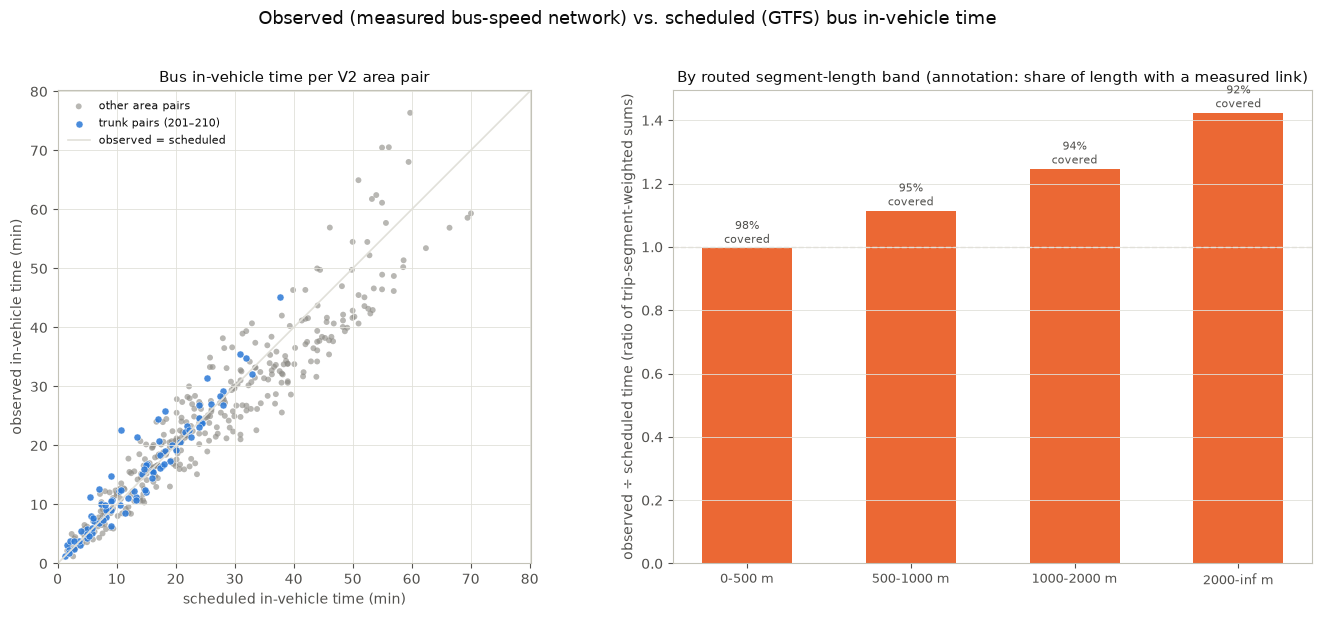

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
ax = axes[0]
is_trunk = skim['o'].between(201, 210) & skim['d'].between(201, 210)
ax.scatter(skim.loc[~is_trunk, 'bus_ivt_scheduled_min'], skim.loc[~is_trunk, 'bus_ivt_observed_min'], s=18, color=MUTED, alpha=0.6, label='other area pairs', edgecolors='none')
ax.scatter(skim.loc[is_trunk, 'bus_ivt_scheduled_min'], skim.loc[is_trunk, 'bus_ivt_observed_min'], s=26, color=BLUE, alpha=0.85, label='trunk pairs (201–210)', edgecolors='white', linewidths=0.4)
lim = float(np.nanmax([skim['bus_ivt_scheduled_min'].max(), skim['bus_ivt_observed_min'].max()])) * 1.05
ax.plot([0, lim], [0, lim], color=GRID, lw=1.2, label='observed = scheduled')
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('scheduled in-vehicle time (min)'); ax.set_ylabel('observed in-vehicle time (min)')
ax.set_title('Bus in-vehicle time per V2 area pair', color=INK, fontsize=11)
ax.legend(frameon=False, fontsize=8, loc='upper left'); ax.grid(True, color=GRID, lw=0.6)
for sp_ in ax.spines.values(): sp_.set_color(AXIS)

ax = axes[1]
xb = np.arange(len(band_df))
ax.bar(xb, band_df['observed_min_wsum'], 0.55, color=ORANGE)
ax.axhline(1.0, color=GRID, lw=1, ls='--')
for x, (r, c) in enumerate(zip(band_df['observed_min_wsum'], band_df['covered_share'])):
    ax.annotate(f'{c:.0%}\ncovered', (x, r), textcoords='offset points', xytext=(0, 4), ha='center', fontsize=8, color=INK2)
ax.set_xticks(xb); ax.set_xticklabels(band_df['band_m'] + ' m', fontsize=9)
ax.set_ylabel('observed ÷ scheduled time (ratio of trip-segment-weighted sums)')
ax.set_title('By routed segment-length band (annotation: share of length with a measured link)', color=INK, fontsize=10.5)
ax.grid(True, color=GRID, lw=0.6, axis='y')
for sp_ in ax.spines.values(): sp_.set_color(AXIS)
fig.suptitle('Observed (measured bus-speed network) vs. scheduled (GTFS) bus in-vehicle time', color=INK, fontsize=13, y=1.02)
plt.tight_layout(); fig.savefig('Output/figures/gtfs_bus_observed_vs_scheduled.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## Findings

- **What was routed.** 7,324 morning-peak trips, 252,114 consecutive stop pairs, 15,929 distinct segments routed once each over the 54,507-link street network (78 % of directed edges carry a measured 07:00–08:00 bus speed). Stops snap to intersection nodes within 24 m (median; 2.6 % beyond 100 m). Routing by shortest length: 84 % of trip-segments route plausibly in the directed graph; a further 13.5 % — short hops that the one-way system turned into loops around the block after node snapping — route plausibly once link direction is ignored; 2.1 % (no measured link, or unreachable) fall back to the schedule. 94 % of routed length lies on links with a measured speed; 97 % of the area-pair segment length is observed.
- **Observed against scheduled.** Per trip the observed in-vehicle time is 1.09 × the scheduled (median; p10 0.86, p90 1.42); Metronit trips run faster than their timetable (0.87), ordinary buses slower (1.10). Per area pair the median ratio is 0.99 (0.86 on Metronit pairs). The pattern by segment length is the informative part: stop-to-stop hops under 500 m — 65 % of all trip-segments — take exactly the scheduled time (ratio 1.00), 500–1,000 m hops 1.11, 1–2 km 1.25, and hops over 2 km 1.42. Since the short hops are where dwell is the largest share of the segment time and they match the schedule, the measured link speeds evidently **include the dwell at stops** (they are space-mean bus speeds over the link, stops included); the long hops are slower than scheduled because those are the arterial and interurban stretches where the 07:00–08:00 speeds carry the peak congestion the timetable pads only partly. Demand-weighted on the 82 direct trunk pairs the observed in-vehicle time is 12.7 min against 10.4 scheduled; on the Metronit's 72 trunk pairs 8.6 against 7.8; on the long pairs (over 30 scheduled minutes) the observed time is 0.88 × the schedule — the timetable of the interurban lines is padded — except from Nazareth, where the observed times to the Haifa trunk are 8–9 minutes above the schedule (62 min to Bat Galim against 54).
- **What this changes.** Step 26 now takes the bus in-vehicle time from this observed skim (the scheduled value is kept alongside as `ivt_scheduled`); the timetable-versus-survey gap of the previous revision splits accordingly into a running-time part (observed − scheduled) and the rest (transfer, the wait for the line actually needed, access). Caveats: shortest-length routing approximates the route between stops; segments routed ignoring link direction (13.5 %) use the measured speed of the direction traversed where it exists; the 2 % fallback segments are scheduled; the speeds are a May 2026 Tuesday-hour average and the timetable a June 2026 service day.
- **Outputs.** `Output/gtfs/bus_segments_observed.csv` (15,929 segments with routed and straight-line length, measured coverage, observed time, flag), `bus_trips_observed.csv.gz` (7,322 trips: scheduled and observed time, covered share), `bus_observed_skim_area_v2.csv` (422 area pairs, bus and Metronit, observed and scheduled, share observed, step 29's value for the check); figure `gtfs_bus_observed_vs_scheduled.png`.